### Loading libraries

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

### Import dataset

In [4]:
data = pd.read_excel("MACHINE LEARNING ASSIGNMENT DATA.xlsx")
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,3.2,0,0,No,Private,Urban,154.5,16.8,never smoked,0
1,2,Male,51.0,0,0,Yes,children,Rural,189.5,16.2,never smoked,0
2,3,Female,25.7,0,0,No,children,Urban,117.4,24.3,formerly smoked,0
3,4,Female,48.7,0,0,Yes,Govt_job,Urban,172.7,17.1,never smoked,0
4,5,Male,77.1,0,0,Yes,Govt_job,Urban,119.2,21.0,formerly smoked,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1500 non-null   int64  
 1   gender             1500 non-null   object 
 2   age                1500 non-null   float64
 3   hypertension       1500 non-null   int64  
 4   heart_disease      1500 non-null   int64  
 5   ever_married       1500 non-null   object 
 6   work_type          1500 non-null   object 
 7   Residence_type     1500 non-null   object 
 8   avg_glucose_level  1500 non-null   float64
 9   bmi                1500 non-null   float64
 10  smoking_status     1500 non-null   object 
 11  stroke             1500 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 140.8+ KB


In [6]:

categorical_df = data.select_dtypes(include=["object", "category"])
categorical_df.head()

,gender,ever_married,work_type,Residence_type,smoking_status
0,Male,No,Private,Urban,never smoked
1,Male,Yes,children,Rural,never smoked
2,Female,No,children,Urban,formerly smoked
3,Female,Yes,Govt_job,Urban,never smoked
4,Male,Yes,Govt_job,Urban,formerly smoked


In [7]:

numerical_df = data.select_dtypes(include=["number"])
numerical_df.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,1,3.2,0,0,154.5,16.8,0
1,2,51.0,0,0,189.5,16.2,0
2,3,25.7,0,0,117.4,24.3,0
3,4,48.7,0,0,172.7,17.1,0
4,5,77.1,0,0,119.2,21.0,0


## Part B: Exploratory Data Analysis 

In [74]:
data.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,1,3.2,0,0,0,1,1,154.5,16.8,1,0
1,2,1,51.0,0,0,1,3,0,189.5,16.2,1,0
2,3,0,25.7,0,0,0,3,1,117.4,24.3,0,0
3,4,0,48.7,0,0,1,0,1,172.7,17.1,1,0
4,5,1,77.1,0,0,1,0,1,119.2,21.0,0,0


In [9]:
data.tail(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1495,1496,Male,61.7,0,0,Yes,children,Rural,153.8,39.9,formerly smoked,0
1496,1497,Male,38.7,0,0,Yes,Govt_job,Rural,84.0,16.2,formerly smoked,0
1497,1498,Male,82.8,1,0,No,Self-employed,Urban,173.2,35.4,never smoked,0
1498,1499,Male,75.4,1,0,Yes,Private,Rural,159.9,17.4,smokes,1
1499,1500,Male,47.2,0,0,Yes,children,Rural,63.9,20.0,formerly smoked,0


In [10]:
print(data.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [11]:
data.describe

<bound method NDFrame.describe of         id  gender   age  hypertension  heart_disease ever_married  \
0        1    Male   3.2             0              0           No   
1        2    Male  51.0             0              0          Yes   
2        3  Female  25.7             0              0           No   
3        4  Female  48.7             0              0          Yes   
4        5    Male  77.1             0              0          Yes   
...    ...     ...   ...           ...            ...          ...   
1495  1496    Male  61.7             0              0          Yes   
1496  1497    Male  38.7             0              0          Yes   
1497  1498    Male  82.8             1              0           No   
1498  1499    Male  75.4             1              0          Yes   
1499  1500    Male  47.2             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban           

In [12]:
missing_values = data.isnull().sum()
missing_values

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

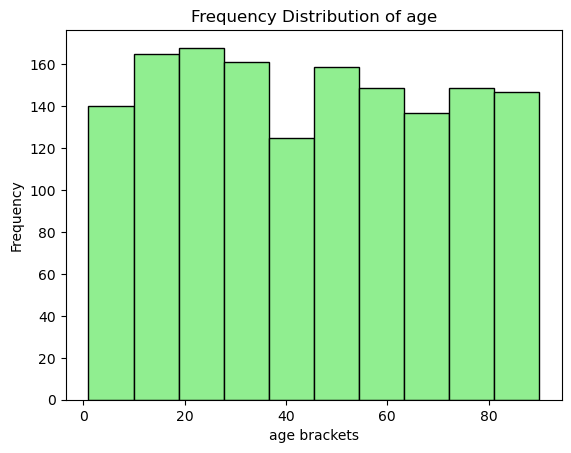

In [13]:
data['age'].plot(kind='hist', bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution of age')
plt.xlabel('age brackets')
plt.ylabel('Frequency')
plt.show()

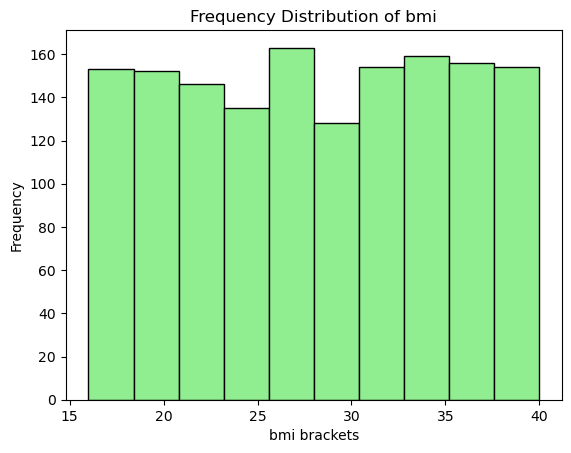

In [14]:
data['bmi'].plot(kind='hist', bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution of bmi')
plt.xlabel('bmi brackets')
plt.ylabel('Frequency')
plt.show()

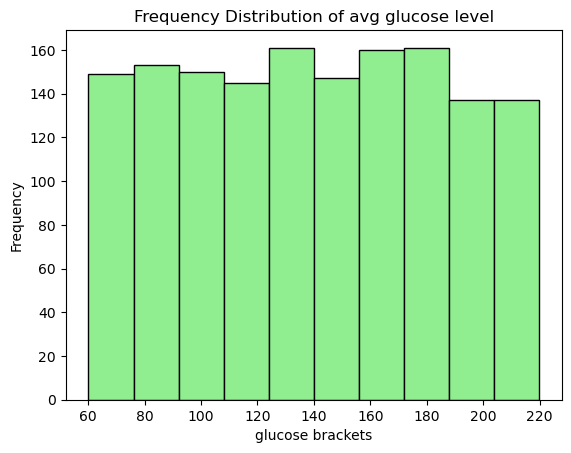

In [15]:
data['avg_glucose_level'].plot(kind='hist', bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution of avg glucose level')
plt.xlabel('glucose brackets')
plt.ylabel('Frequency')
plt.show()

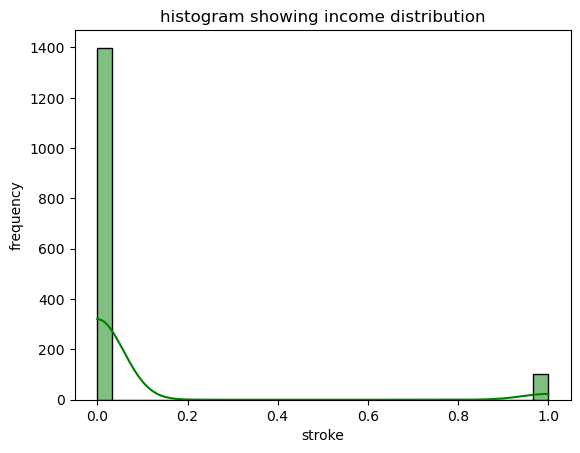

In [75]:
sns.histplot(data["stroke"], bins = 30, kde = True ,color = "green")
plt.title("histogram showing income distribution")
plt.xlabel("stroke")
plt.ylabel("frequency")
plt.show()

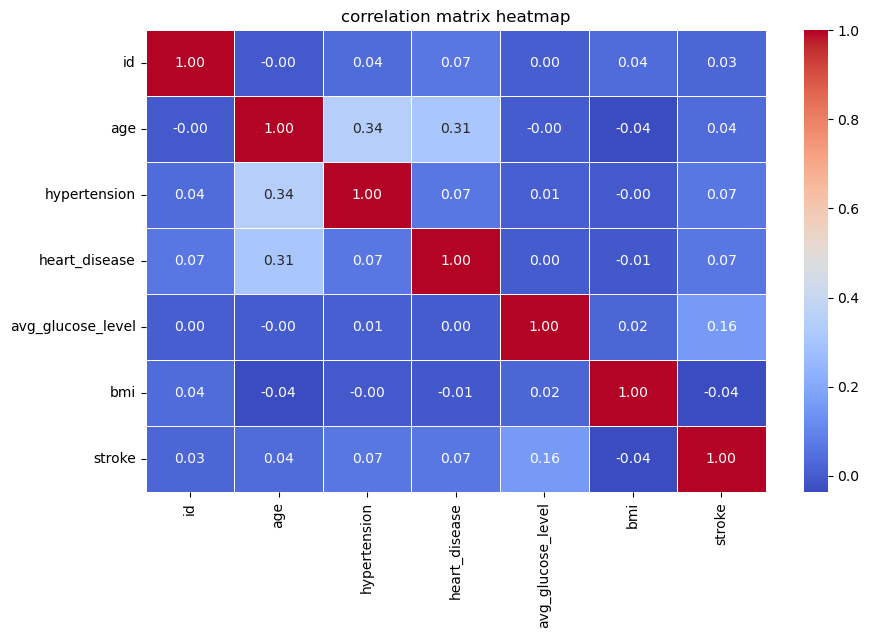

In [17]:
plt.figure(figsize = (10, 6))
corr_matrix = data.select_dtypes(include = [np.number]).corr()
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f",linewidths = 0.5)
plt. title("correlation matrix heatmap")
plt.show()

## Part C: Data Preprocessing 

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Loop through each column name in your categorical dataframe
for col in categorical_df.columns:
    data[col] = le.fit_transform(data[col])
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,1,3.2,0,0,0,1,1,154.5,16.8,1,0
1,2,1,51.0,0,0,1,3,0,189.5,16.2,1,0
2,3,0,25.7,0,0,0,3,1,117.4,24.3,0,0
3,4,0,48.7,0,0,1,0,1,172.7,17.1,1,0
4,5,1,77.1,0,0,1,0,1,119.2,21.0,0,0


In [19]:
x = data.drop('stroke', axis = 1)

y = data['stroke']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state = 42)

In [25]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)


x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, y_train)

print("Class distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

Class distribution before SMOTE:
stroke
0    1115
1      85
Name: count, dtype: int64

Class distribution after SMOTE:
stroke
0    1115
1    1115
Name: count, dtype: int64


## Random forest classification

In [29]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Initialize the base model
rf_base = RandomForestClassifier(random_state=42)

# 3. Set up GridSearchCV
# cv=5 means 5-fold cross-validation. n_jobs=-1 uses all available processor cores.
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=2)

# 4. Fit the grid search to the resampled training data
grid_search.fit(x_train_resampled, y_train_resampled)

# 5. View the best parameters and score
print("Best Parameters found: ", grid_search.best_params_)
print("Best Cross-Validation Score: ", grid_search.best_score_)

# 6. Extract the best model to use for predictions
best_rf_model = grid_search.best_estimator_

#Predict using the tuned model
y_pred_tuned = best_rf_model.predict(x_test_scaled)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters found:  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score:  0.9636771300448432


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
y_pred_prona = best_rf_model.predict_proba(x_test_scaled)[:, 1]

print('\nclassification report:')
print(classification_report(y_test, y_pred_tuned))



classification report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       284
           1       0.12      0.12      0.12        16

    accuracy                           0.90       300
   macro avg       0.53      0.54      0.54       300
weighted avg       0.91      0.90      0.90       300



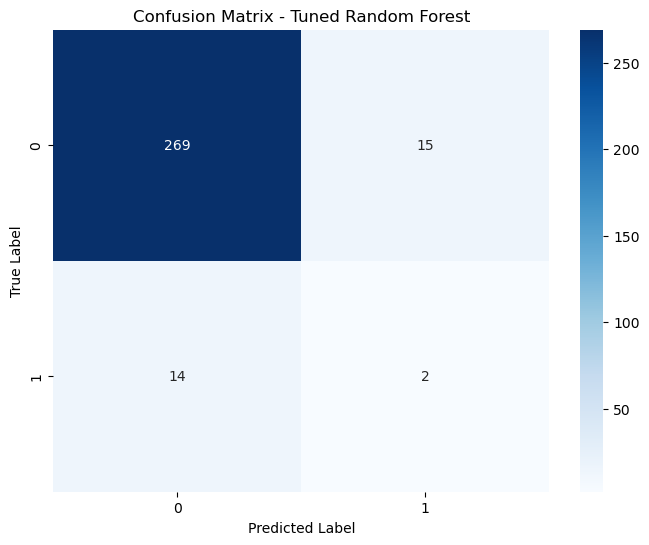

In [39]:
cm = confusion_matrix(y_test, y_pred_tuned)

# 4. Plot the Confusion Matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

ROC AUC Score: 0.5976



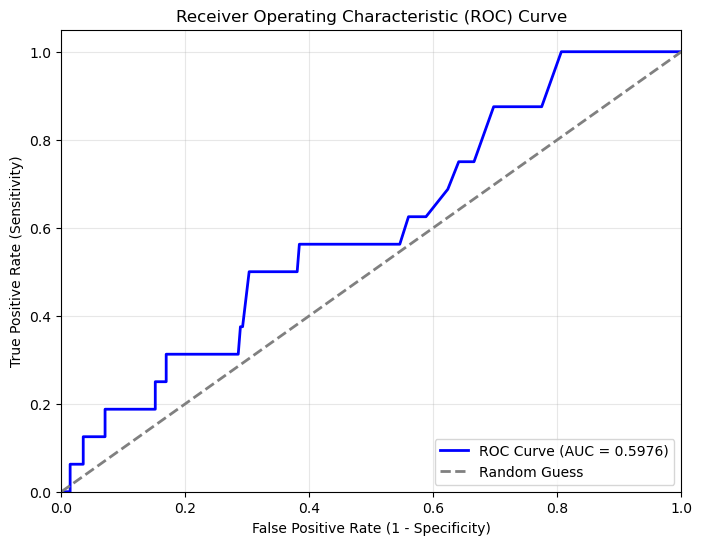

In [40]:
# 1. Get the predicted probabilities for the positive class (class 1)
y_pred_proba = best_rf_model.predict_proba(x_test_scaled)[:, 1]

# 2. Calculate the ROC curve points (False Positive Rate, True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Calculate the Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}\n")

# 4. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')

# Plot the diagonal line representing a random guess
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guess')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Part E: XGBoost Classification 

In [45]:
from xgboost import XGBRegressor
xgb_baseline=XGBRegressor()
xgb_baseline.fit(x_train_resampled, y_train_resampled)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [46]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    "sabsample": [0.8,1],
    "colsample_bytree":[0.8,1]
}

In [47]:
grid_search=GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    verbose=2,
    n_jobs=1
)

In [48]:
y_pred1=xgb_baseline.predict(x_test_scaled)

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Convert continuous probabilities to binary predictions (0 or 1)
threshold = 0.5
y_pred1_binary = (y_pred1 > threshold).astype(int)

# 2. Calculate the metrics
accuracy = accuracy_score(y_test, y_pred1_binary)
precision = precision_score(y_test, y_pred1_binary)
recall = recall_score(y_test, y_pred1_binary)
f1 = f1_score(y_test, y_pred1_binary)

# ROC-AUC uses the continuous probabilities, NOT the binary predictions
roc_auc = roc_auc_score(y_test, y_pred1)

# 3. Print the results
print("--- XGBoost Model Performance ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")


--- XGBoost Model Performance ---
Accuracy:  0.8933
Precision: 0.1364
Recall:    0.1875
F1-score:  0.1579
ROC-AUC:   0.5858


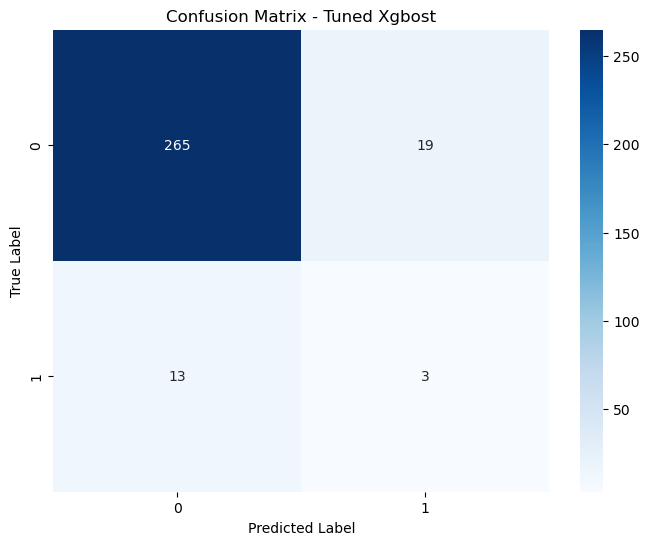

In [52]:
cm = confusion_matrix(y_test, y_pred1_binary)

# 4. Plot the Confusion Matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Xgbost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

ROC AUC Score: 0.5603



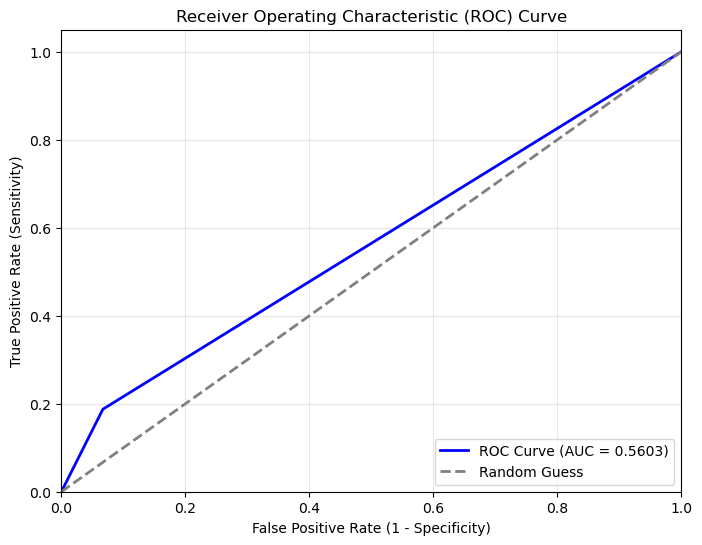

In [53]:
y_pred_proba1 = best_rf_model.predict_proba(x_test_scaled)[:, 1]

# 2. Calculate the ROC curve points (False Positive Rate, True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_pred1_binary)

# 3. Calculate the Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, y_pred1_binary)
print(f"ROC AUC Score: {auc_score:.4f}\n")

# 4. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')

# Plot the diagonal line representing a random guess
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guess')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

###  Part F: Support Vector Machine 

In [68]:
from sklearn.svm import SVC
kernels = ['linear', 'rbf']

for kernel in kernels:

    model1 = SVC(kernel=kernel, random_state=42)

    model1.fit(x_train_resampled, y_train_resampled)

    predictions = model.predict(x_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f"{kernel} kernel accuracy: {accuracy:.4f}")

linear kernel accuracy: 0.9467
rbf kernel accuracy: 0.9467


In [69]:
y_pred2 = model.predict(x_test)

In [70]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       284
           1       0.00      0.00      0.00        16

    accuracy                           0.95       300
   macro avg       0.47      0.50      0.49       300
weighted avg       0.90      0.95      0.92       300




confusion matrix:


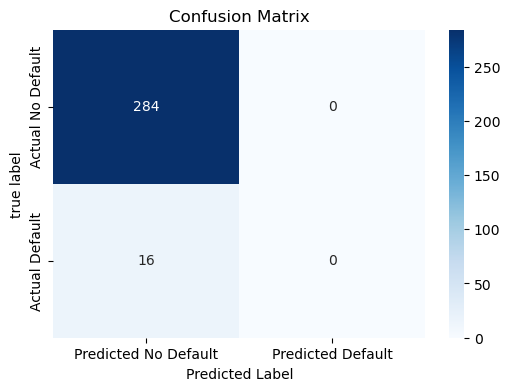

In [71]:
print("\nconfusion matrix:")
cm = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Predicted No Default', 'Predicted Default'],
           yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('true label')
plt.show()

In [72]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ==========================================
# 1. Gather Predictions and Probabilities/Scores
# ==========================================

# Random Forest
# (Assuming 'best_rf_model' is your tuned model and 'y_pred_tuned' are its binary predictions)
y_prob_rf = best_rf_model.predict_proba(x_test_scaled)[:, 1]

# XGBoost
# (Assuming 'y_pred1' contains your continuous probabilities from earlier)
y_pred_xgb = (y_pred1 > 0.5).astype(int) 
y_prob_xgb = y_pred1

# SVC
# (Using decision_function for ROC-AUC since SVC doesn't output probabilities by default)
# Make sure to use x_test or x_test_scaled depending on how you trained model1
y_scores_svc = model1.decision_function(x_test) 
# y_pred2 are your binary predictions for SVC from cell [64]

# ==========================================
# 2. Define a function to calculate metrics
# ==========================================
def evaluate_model(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

# ==========================================
# 3. Calculate metrics for all three models
# ==========================================
metrics_rf = evaluate_model(y_test, y_pred_tuned, y_prob_rf)
metrics_xgb = evaluate_model(y_test, y_pred_xgb, y_prob_xgb)
metrics_svc = evaluate_model(y_test, y_pred2, y_scores_svc)

# ==========================================
# 4. Create and display the comparison table
# ==========================================
# Combine dictionaries into a DataFrame
comparison_df = pd.DataFrame({
    'Random Forest': metrics_rf,
    'XGBoost': metrics_xgb,
    'SVC': metrics_svc
}).T  # .T transposes the table so models are rows and metrics are columns

# Display the table beautifully 
print("--- Model Comparison ---")
display(comparison_df.round(4)) # rounds to 4 decimal places for readability

--- Model Comparison ---


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Random Forest,0.9033,0.1176,0.1250,0.1212,0.5976
XGBoost,0.8933,0.1364,0.1875,0.1579,0.5858
SVC,0.9467,0.0000,0.0000,0.0000,0.5000
